# Phân tích các yếu tố ảnh hưởng đến rating của phim

---

## 1. Phát biểu bài toán

Bài làm tập trung phân tích dữ liệu phim để đánh giá tính khả thi của việc xây dựng mô hình dự đoán điểm rating (biến mục tiêu Y) từ các yếu tố như năm phát hành, số lượt bình chọn, thể loại, thời lượng và ngân sách. Đây là bài toán hồi quy vì rating là biến số liên tục (thang 0–10). Hai câu hỏi cần trả lời: (1) Bài toán có khả thi về mặt dữ liệu không và vì sao? (2) Tập đặc trưng nào nên dùng cho mô hình? Phạm vi bài thi GK dừng ở phân tích, làm sạch, trực quan hóa và đánh giá khả thi; phần xây mô hình sẽ thực hiện ở bài tập sau.

## 2. Thu thập dữ liệu

Dữ liệu lấy từ The Movie Database (TMDB) qua API. Script `scrape.py` thu thập bằng cách: lấy danh sách link phim từ trang listing, trích `movie_id` từ URL rồi gọi API `/movie/{id}` để lấy tên phim, năm phát hành, rating, số vote, thể loại, thời lượng (runtime) và ngân sách (budget); chỉ lưu bản ghi đủ thông tin. Tập dữ liệu có hơn 1000 mẫu và 7 biến: Movie_name, Release_year, Rating, Voting_count, Genre, Run_time, Budget. Trong notebook em đọc dữ liệu từ file Excel đã crawl sẵn (`raw data/data.xlsx`).

In [207]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Thiết lập đồ thị: matplotlib + seaborn
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
sns.set_palette('husl')

# Đường dẫn: chạy từ thư mục notebooks/ (RAW_PATH = ../raw data/data.xlsx)
RAW_PATH = os.path.join('..', 'raw data', 'data.xlsx')
if not os.path.exists(RAW_PATH):
    RAW_PATH = os.path.join('raw data', 'data.xlsx')
CLEAN_DIR = os.path.join('..', 'clean data') if os.path.exists(os.path.join('..', 'raw data')) else os.path.join('clean data')
os.makedirs(CLEAN_DIR, exist_ok=True)

df = pd.read_excel(RAW_PATH)
# Loại bỏ cột index không tên (nếu có) khi đọc từ Excel
if df.columns[0] == 'Unnamed: 0' or (df.columns[0] != 'Movie_name' and 'Movie_name' in df.columns):
    df = df.drop(columns=[c for c in df.columns if 'Unnamed' in str(c)], errors='ignore')
print('Kích thước:', df.shape)
print('Các cột:', list(df.columns))
df.head(10)

Kích thước: (1826, 7)
Các cột: ['Movie_name', 'Release_year', 'Rating', 'Voting_count', 'Genre', 'Run_time', 'Budget']


,Movie_name,Release_year,Rating,Voting_count,Genre,Run_time,Budget
0,Life Is Beautiful,1997,8.4,13846.0,"Comedy, Drama",116 min,"$20,000,000"
1,Cinderella,2015,6.8,7337.0,"Romance, Fantasy, Family, Drama",105 min,"$95,000,000"
2,My Neighbor Totoro,1988,8.1,8672.0,"Fantasy, Animation, Family",86 min,"$3,700,000"
3,Everything Everywhere All at Once,2022,7.7,7735.0,"Action, Adventure, Science Fiction",140 min,"$25,000,000"
4,The Hobbit: The Desolation of Smaug,2013,7.6,13998.0,"Fantasy, Adventure, Action",161 min,"$250,000,000"
5,Downton Abbey: A New Era,2022,7.2,596.0,"Drama, Romance",124 min,"$40,000,000"
6,Madagascar,2005,6.9,11581.0,"Family, Animation, Adventure, Comedy",86 min,"$75,000,000"
7,Captain America: Civil War,2016,7.4,23806.0,"Adventure, Action, Science Fiction",147 min,"$250,000,000"
8,Scouts Guide to the Zombie Apocalypse,2015,6.6,2093.0,"Comedy, Horror",93 min,"$15,000,000"
9,Platoon,1986,7.7,5007.0,"Drama, War, Action",120 min,"$6,000,000"


### 2.1 Thống kê mô tả và thông tin dataset

Em xem cấu trúc dataset (info), kiểu dữ liệu từng cột, số lượng missing và thống kê mô tả các biến số.

In [208]:
print('=== Thông tin dataset ===')
df.info()
print('\n=== Kiểu dữ liệu ===')
print(df.dtypes)
print('\n=== Missing values ===')
print(df.isnull().sum())
print('\n=== Thống kê mô tả (biến số) ===')
print(df.describe(include=[np.number]))
print('\n=== Thống kê mô tả (tất cả) ===')
df.describe(include='all')

=== Thông tin dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1826 entries, 0 to 1825
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Movie_name    1826 non-null   object 
 1   Release_year  1826 non-null   int64  
 2   Rating        1822 non-null   float64
 3   Voting_count  1822 non-null   float64
 4   Genre         1823 non-null   object 
 5   Run_time      1821 non-null   object 
 6   Budget        1826 non-null   object 
dtypes: float64(2), int64(1), object(4)
memory usage: 100.0+ KB

=== Kiểu dữ liệu ===
Movie_name       object
Release_year      int64
Rating          float64
Voting_count    float64
Genre            object
Run_time         object
Budget           object
dtype: object

=== Missing values ===
Movie_name      0
Release_year    0
Rating          4
Voting_count    4
Genre           3
Run_time        5
Budget          0
dtype: int64

=== Thống kê mô tả (biến số) ===
       Release_y

,Movie_name,Release_year,Rating,Voting_count,Genre,Run_time,Budget
count,1826,1826.000000,1822.000000,1822.000000,1823,1821,1826
unique,1798,NaN,NaN,NaN,719,154,404
top,The Jungle Book,NaN,NaN,NaN,Drama,102 min,"$15,000,000"
freq,2,NaN,NaN,NaN,70,46,53
mean,NaN,2006.979737,6.803183,5497.012075,NaN,NaN,NaN
std,NaN,16.895914,1.100332,6037.050733,NaN,NaN,NaN
min,NaN,1916.000000,0.000000,0.000000,NaN,NaN,NaN
25%,NaN,2000.000000,6.400000,919.250000,NaN,NaN,NaN
50%,NaN,2011.000000,6.900000,3568.000000,NaN,NaN,NaN
75%,NaN,2019.000000,7.500000,7905.500000,NaN,NaN,NaN


### 2.1.1 Làm sạch lần 1

Em thực hiện làm sạch trên bản copy của `df`: (1) Chuyển dữ liệu sang dạng chuẩn — Rating dùng hàm parse_rating (xử lý chuỗi và dấu phẩy), Voting_count và Release_year ép sang số; Run_time bỏ hậu tố " min" rồi chuyển thành số phút (cột Runtime_min); Budget bỏ "$" và dấu phẩy thành số (cột Budget_num); Genre và Movie_name strip khoảng trắng. (2) Xóa dòng thiếu ở bất kỳ cột nào trong số Rating, Voting_count, Release_year, Runtime_min, Budget_num (dropna subset). (3) Xóa bản ghi trùng (drop_duplicates). Ở bước này em không đặt thêm điều kiện lọc theo khoảng giá trị; việc lọc outlier thực hiện ở mục 3.

In [209]:
import re

def parse_rating(x):
    if pd.isna(x): return np.nan
    s = str(x).strip().lower().replace(',', '.')
    m = re.search(r"(\d+(?:\.\d+)?)", s)
    return float(m.group(1)) if m else np.nan

def parse_runtime(s):
    if pd.isna(s): return np.nan
    s = str(s).replace(' min', '').replace(',', '').strip()
    try: return float(s)
    except ValueError: return np.nan

def parse_budget(s):
    if pd.isna(s): return np.nan
    s = str(s).replace('$', '').replace(',', '').strip()
    try: return float(s)
    except ValueError: return np.nan

df_first_clean = df.copy()

# Chuẩn hóa về dạng chuẩn (bỏ $, " min", ép kiểu số)
df_first_clean['Rating'] = pd.to_numeric(df_first_clean['Rating'].apply(parse_rating), errors='coerce')
df_first_clean['Voting_count'] = pd.to_numeric(df_first_clean['Voting_count'], errors='coerce')
df_first_clean['Release_year'] = pd.to_numeric(df_first_clean['Release_year'], errors='coerce')
df_first_clean['Runtime_min'] = df_first_clean['Run_time'].apply(parse_runtime)
df_first_clean['Budget_num'] = df_first_clean['Budget'].apply(parse_budget)
df_first_clean['Genre'] = df_first_clean['Genre'].astype(str).str.strip()
df_first_clean['Movie_name'] = df_first_clean['Movie_name'].astype(str).str.strip()

# Xóa dữ liệu lỗi và xóa luôn các bộ bị missing (thiếu ở bất kỳ cột quan trọng nào)
df_first_clean = df_first_clean.dropna(subset=['Rating', 'Voting_count', 'Release_year', 'Runtime_min', 'Budget_num'])

# Xóa trùng lặp (không đặt điều kiện lọc Rating/Voting_count/năm ở bước này)
df_first_clean = df_first_clean.drop_duplicates()

print('Sau làm sạch lần 1:', df_first_clean.shape)

Sau làm sạch lần 1: (1817, 9)


### 2.1.2 Xuất file làm sạch lần 1

Kết quả làm sạch lần 1 được lưu vào file `first_clean.xlsx` với đúng 7 cột như dữ liệu gốc: Movie_name, Release_year, Rating, Voting_count, Genre, Run_time, Budget. Cột Run_time lưu số phút (từ Runtime_min), cột Budget lưu số (từ Budget_num), không thêm cột mới.

In [210]:
# Xuất file giữ đúng 7 cột như dữ liệu gốc, thay dữ liệu đã chuẩn hóa vào (không thêm cột)
FIRST_CLEAN_PATH = os.path.join(CLEAN_DIR, 'first_clean.xlsx')
export_first = df_first_clean[['Movie_name', 'Release_year', 'Rating', 'Voting_count', 'Genre']].copy()
export_first['Run_time'] = df_first_clean['Runtime_min']
export_first['Budget'] = df_first_clean['Budget_num']
export_first.to_excel(FIRST_CLEAN_PATH, index=False)
print('Đã lưu:', FIRST_CLEAN_PATH)

Đã lưu: ..\clean data\first_clean.xlsx


### 2.2 Trực quan hóa đơn biến

Em vẽ phân bố của các biến quan trọng trên dữ liệu sau làm sạch lần 1 (df_first_clean): histogram (và kde cho Rating) cho Rating, Voting_count, Release_year, thời lượng (Runtime_min), ngân sách (chỉ phim có budget > 0), và biểu đồ top thể loại (Genre).

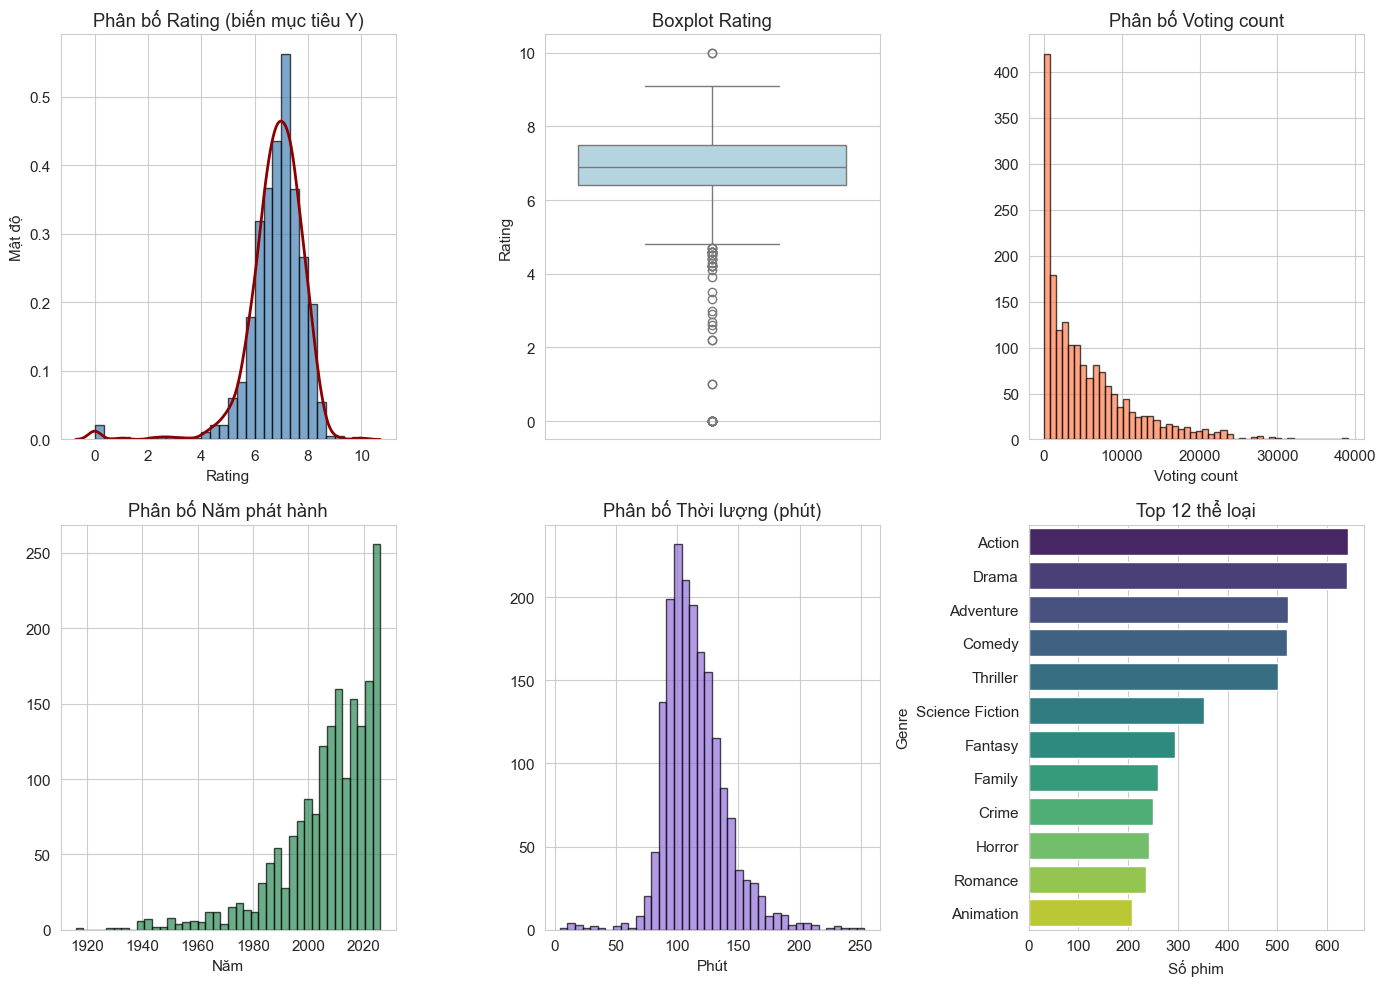

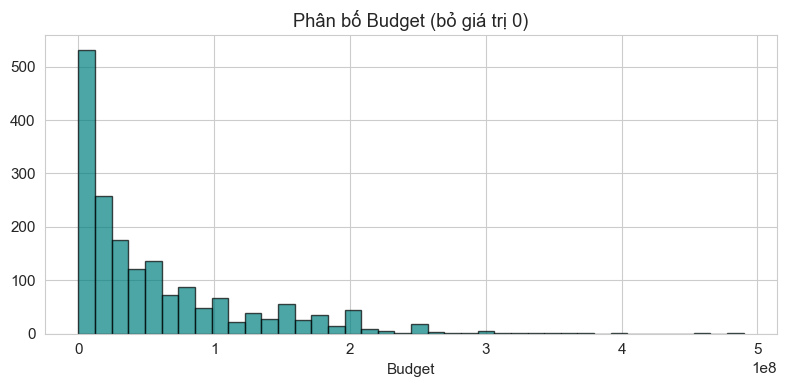

In [211]:
# Dùng trực tiếp dữ liệu đã làm sạch lần 1 (đã chuẩn hóa), không chuẩn hóa thêm
df_plot = df_first_clean.copy()

# --- Trực quan đơn biến: 6 đồ thị (matplotlib + seaborn) ---
fig, axes = plt.subplots(2, 3, figsize=(14, 10))

# 1. Phân bố Rating (histogram + KDE)
axes[0,0].hist(df_plot['Rating'].dropna(), bins=30, edgecolor='black', alpha=0.7, density=True, color='steelblue')
sns.kdeplot(df_plot['Rating'].dropna(), ax=axes[0,0], color='darkred', linewidth=2)
axes[0,0].set_title('Phân bố Rating (biến mục tiêu Y)')
axes[0,0].set_xlabel('Rating')
axes[0,0].set_ylabel('Mật độ')

# 2. Boxplot Rating
sns.boxplot(y=df_plot['Rating'], ax=axes[0,1], color='lightblue')
axes[0,1].set_title('Boxplot Rating')
axes[0,1].set_ylabel('Rating')

# 3. Phân bố Voting_count (histogram)
df_plot['Voting_count'].dropna().hist(ax=axes[0,2], bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[0,2].set_title('Phân bố Voting count')
axes[0,2].set_xlabel('Voting count')

# 4. Phân bố Release_year
df_plot['Release_year'].dropna().hist(ax=axes[1,0], bins=40, edgecolor='black', alpha=0.7, color='seagreen')
axes[1,0].set_title('Phân bố Năm phát hành')
axes[1,0].set_xlabel('Năm')

# 5. Phân bố Run_time (phút) — dùng Runtime_min đã chuẩn hóa ở bước trên
df_plot['Runtime_min'].hist(ax=axes[1,1], bins=40, edgecolor='black', alpha=0.7, color='mediumpurple')
axes[1,1].set_title('Phân bố Thời lượng (phút)')
axes[1,1].set_xlabel('Phút')

# 6. Top thể loại (bar horizontal - seaborn)
genre_counts = df_plot['Genre'].str.split(', ').explode().str.strip().value_counts().head(12)
sns.barplot(x=genre_counts.values, y=genre_counts.index, ax=axes[1,2], palette='viridis')
axes[1,2].set_title('Top 12 thể loại')
axes[1,2].set_xlabel('Số phim')
plt.tight_layout()
plt.show()

# Phân bố Budget (nhiều giá trị 0 hoặc nhỏ, vẽ riêng)
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
budget_valid = df_plot['Budget_num'].dropna()
budget_valid = budget_valid[budget_valid > 0]
budget_valid.hist(ax=ax, bins=40, edgecolor='black', alpha=0.7, color='teal')
ax.set_title('Phân bố Budget (bỏ giá trị 0)')
ax.set_xlabel('Budget')
plt.tight_layout()
plt.show()

### 2.3 Xác định outlier

Em xác định outlier theo phương pháp IQR cho ba biến: Runtime_min, Budget_num (chỉ xét các phim có budget > 0 khi tính IQR), Voting_count. Với mỗi biến tính Q1, Q3 và khoảng [Q1 − 1,5×IQR, Q3 + 1,5×IQR]; giá trị ngoài khoảng này coi là outlier. Em lưu các ngưỡng (low, high) vào dictionary OUTLIER_BOUNDS và định nghĩa các hàm in_bounds, build_outlier_mask, filter_by_outlier_bounds để dùng ở bước lọc sau. Với Budget: dòng có budget = 0 hoặc NaN vẫn được giữ, chỉ coi là outlier khi budget > 0 và nằm ngoài khoảng IQR.

In [212]:
# Xác định outlier theo IQR (Q1 - 1.5*IQR, Q3 + 1.5*IQR) — dùng df_first_clean
def iqr_bounds(series):
    """Trả về (low, high) ngoài đó là outlier."""
    s = series.dropna()
    if len(s) == 0:
        return np.nan, np.nan
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    return low, high

# Lấy cột số (Runtime_min, Budget_num, Voting_count)
rt = df_first_clean['Runtime_min'].dropna()
budget = df_first_clean['Budget_num'].dropna()
budget_pos = budget[budget > 0]  # IQR chỉ trên budget > 0
vc = df_first_clean['Voting_count'].dropna()

bounds_runtime = iqr_bounds(rt)
bounds_budget = iqr_bounds(budget_pos) if len(budget_pos) > 0 else (np.nan, np.nan)
bounds_voting = iqr_bounds(vc)

# Lưu lại để dùng cho bước lọc bên dưới
OUTLIER_BOUNDS = {
    'Runtime_min': bounds_runtime,
    'Budget_num': bounds_budget,
    'Voting_count': bounds_voting,
}

def in_bounds(series, low, high):
    """True nếu giá trị nằm trong [low, high] hoặc NaN. Nếu bound NaN thì luôn True."""
    if np.isnan(low) and np.isnan(high):
        return pd.Series(True, index=series.index)
    return series.isna() | ((series >= low) & (series <= high))

def build_outlier_mask(df, bounds_dict):
    """Trả về mask True cho dòng được giữ (không phải outlier)."""
    low_rt, high_rt = bounds_dict['Runtime_min']
    low_bud, high_bud = bounds_dict['Budget_num']
    low_vc, high_vc = bounds_dict['Voting_count']
    mask_rt = in_bounds(df['Runtime_min'], low_rt, high_rt)
    if np.isnan(low_bud) or np.isnan(high_bud):
        mask_bud = pd.Series(True, index=df.index)
    else:
        mask_bud = df['Budget_num'].isna() | (df['Budget_num'] <= 0) | ((df['Budget_num'] >= low_bud) & (df['Budget_num'] <= high_bud))
    mask_vc = in_bounds(df['Voting_count'], low_vc, high_vc)
    return mask_rt & mask_bud & mask_vc

def filter_by_outlier_bounds(df, bounds_dict):
    """Lọc dataframe theo OUTLIER_BOUNDS; trả về df chỉ gồm dòng không phải outlier."""
    mask = build_outlier_mask(df, bounds_dict)
    return df.loc[mask].copy()

# Đếm outlier: nằm ngoài [low, high] (NaN không tính là outlier)
def count_outliers(series, low, high):
    valid = series.notna()
    out = valid & ((series < low) | (series > high))
    return out.sum()

# Budget: chỉ coi là outlier khi value > 0 và ngoài khoảng (giữ 0 và NaN)
def count_outliers_budget(series, low, high):
    if np.isnan(low) or np.isnan(high):
        return 0
    return ((series > 0) & ((series < low) | (series > high))).sum()

n_out_rt = count_outliers(df_first_clean['Runtime_min'], *bounds_runtime)
n_out_bud = count_outliers_budget(df_first_clean['Budget_num'], *bounds_budget)
n_out_vc = count_outliers(df_first_clean['Voting_count'], *bounds_voting)

print('Outlier (IQR) — ngưỡng và số lượng:')
print('  Runtime_min :', bounds_runtime, '→', n_out_rt, 'outlier')
print('  Budget_num  :', bounds_budget, '→', n_out_bud, 'outlier')
print('  Voting_count:', bounds_voting, '→', n_out_vc, 'outlier')
print('OUTLIER_BOUNDS đã lưu để dùng ở bước lọc bên dưới.')

Outlier (IQR) — ngưỡng và số lượng:
  Runtime_min : (np.float64(54.5), np.float64(170.5)) → 64 outlier
  Budget_num  : (np.float64(-96000000.0), np.float64(185600000.0)) → 108 outlier
  Voting_count: (np.float64(-9535.0), np.float64(18393.0)) → 86 outlier
OUTLIER_BOUNDS đã lưu để dùng ở bước lọc bên dưới.


## 3. Chuẩn hóa và lọc dữ liệu

Em bắt đầu từ dữ liệu đã làm sạch lần 1 (df_first_clean). (1) Tạo bản copy df_clean; đảm bảo có cột số Runtime_min và Budget_num (từ Run_time và Budget nếu chưa có); strip khoảng trắng cho Genre và Movie_name. (2) Lọc bỏ các dòng là outlier theo OUTLIER_BOUNDS đã tính ở 2.3. (3) Chuẩn hóa định lượng ba cột Voting_count, Runtime_min, Budget_num về đoạn [0, 1] bằng MinMaxScaler (giá trị thiếu điền bằng median trước khi scale); các cột khác giữ nguyên. Kết quả cuối cùng được lưu vào file data_after_normalize_clean.xlsx.

In [213]:
# Dùng dữ liệu đã làm sạch lần 1; chỉ chuyển đổi để dễ vẽ, không lọc dữ liệu
df_clean = df_first_clean.copy()

# Chuyển đổi sang cột số: Runtime_min, Budget_num (để dễ vẽ và dùng sau)
if 'Runtime_min' not in df_clean.columns and 'Run_time' in df_clean.columns:
    df_clean['Runtime_min'] = pd.to_numeric(df_clean['Run_time'], errors='coerce')
elif 'Runtime_min' not in df_clean.columns:
    df_clean['Runtime_min'] = pd.to_numeric(df_clean.get('Run_time'), errors='coerce')
if 'Budget_num' not in df_clean.columns and 'Budget' in df_clean.columns:
    df_clean['Budget_num'] = pd.to_numeric(df_clean['Budget'], errors='coerce')

# Chuẩn hóa chuỗi (strip khoảng trắng)
df_clean['Genre'] = df_clean['Genre'].astype(str).str.strip()
df_clean['Movie_name'] = df_clean['Movie_name'].astype(str).str.strip()

print('Shape sau chuẩn hóa:', df_clean.shape)
print('Missing (các cột chính):')
print(df_clean[['Rating', 'Voting_count', 'Release_year', 'Runtime_min', 'Budget_num']].isnull().sum())

Shape sau chuẩn hóa: (1817, 9)
Missing (các cột chính):
Rating          0
Voting_count    0
Release_year    0
Runtime_min     0
Budget_num      0
dtype: int64


### Lọc theo điều kiện outlier

Em gọi hàm filter_by_outlier_bounds(df_clean, OUTLIER_BOUNDS): loại các dòng có ít nhất một trong ba biến (Runtime_min, Budget_num, Voting_count) nằm ngoài khoảng hợp lệ đã lưu trong OUTLIER_BOUNDS. Dòng có Budget NaN hoặc 0 vẫn được giữ.

In [214]:
# Lọc df_clean theo OUTLIER_BOUNDS (dùng hàm filter_by_outlier_bounds)
n_before = len(df_clean)
df_clean = filter_by_outlier_bounds(df_clean, OUTLIER_BOUNDS)
n_after = len(df_clean)

print('Sau lọc outlier: giữ', n_after, 'dòng (bỏ', n_before - n_after, 'dòng).')
print('Shape df_clean:', df_clean.shape)

Sau lọc outlier: giữ 1589 dòng (bỏ 228 dòng).
Shape df_clean: (1589, 9)


### Chuẩn hóa định lượng (scale)

Em scale ba cột Voting_count, Runtime_min, Budget_num về đoạn [0, 1] bằng MinMaxScaler của sklearn. Trước khi fit_transform em điền giá trị thiếu bằng median của từng cột. Release_year, Rating và các cột chuỗi không đổi.

In [215]:
# Chuẩn hóa định lượng: chỉ scale Voting_count, Runtime_min, Budget_num về [0, 1]
from sklearn.preprocessing import MinMaxScaler

scale_cols = ['Voting_count', 'Runtime_min', 'Budget_num']
X = df_clean[scale_cols].copy()
X_filled = X.fillna(X.median())
scaler = MinMaxScaler()
df_clean[scale_cols] = scaler.fit_transform(X_filled)

print('Đã chuẩn hóa định lượng (MinMax 0–1) các cột:', scale_cols)
print('Các cột còn lại (Release_year, Rating, ...) giữ nguyên.')
print('Khoảng giá trị sau scale:', df_clean[scale_cols].min().min().round(4), '–', df_clean[scale_cols].max().max().round(4))

Đã chuẩn hóa định lượng (MinMax 0–1) các cột: ['Voting_count', 'Runtime_min', 'Budget_num']
Các cột còn lại (Release_year, Rating, ...) giữ nguyên.
Khoảng giá trị sau scale: 0.0 – 1.0


### Lưu file sau chuẩn hóa và làm sạch

Em xuất df_clean ra file `data_after_normalize_clean.xlsx` với đúng 7 cột: Movie_name, Release_year, Rating, Voting_count, Genre, Run_time, Budget. Ba cột Voting_count, Run_time, Budget lưu giá trị đã scale (0–1); Release_year, Rating và chuỗi giữ nguyên. Đồ thị so sánh "sau" phía dưới đọc từ file này.

In [216]:
# Lưu đúng dữ liệu đã chuẩn hóa (ký tự + định lượng MinMax 0–1) và đã xóa outlier: 7 cột
os.makedirs(CLEAN_DIR, exist_ok=True)
PATH_AFTER_NORMALIZE = os.path.join(CLEAN_DIR, 'data_after_normalize_clean.xlsx')

# df_clean đã qua: chuẩn hóa chuỗi, lọc outlier, chuẩn hóa định lượng (MinMax) cho Voting_count, Runtime_min, Budget_num
export_clean = pd.DataFrame({
    'Movie_name': df_clean['Movie_name'].astype(str).str.strip(),
    'Release_year': pd.to_numeric(df_clean['Release_year'], errors='coerce'),
    'Rating': pd.to_numeric(df_clean['Rating'], errors='coerce'),
    'Voting_count': pd.to_numeric(df_clean['Voting_count'], errors='coerce'),
    'Genre': df_clean['Genre'].astype(str).str.strip(),
    'Run_time': pd.to_numeric(df_clean['Runtime_min'], errors='coerce'),
    'Budget': pd.to_numeric(df_clean['Budget_num'], errors='coerce')
})
export_clean.to_excel(PATH_AFTER_NORMALIZE, index=False)

print('Đã lưu (chuẩn hóa ký tự + scale 0–1 cho Voting_count/Run_time/Budget, còn lại giữ nguyên) và đã xóa outlier:', PATH_AFTER_NORMALIZE)
print('Số dòng:', len(export_clean), '| Cột:', list(export_clean.columns))

Đã lưu (chuẩn hóa ký tự + scale 0–1 cho Voting_count/Run_time/Budget, còn lại giữ nguyên) và đã xóa outlier: ..\clean data\data_after_normalize_clean.xlsx
Số dòng: 1589 | Cột: ['Movie_name', 'Release_year', 'Rating', 'Voting_count', 'Genre', 'Run_time', 'Budget']


### So sánh phân bố trước và sau chuẩn hóa và làm sạch

Em vẽ hai nhóm đồ thị để so sánh: đồ thị 1 dùng dữ liệu từ `first_clean.xlsx` (trước chuẩn hóa và xóa outlier), đồ thị 2 từ `data_after_normalize_clean.xlsx` (sau lọc outlier và scale). Mỗi nhóm gồm histogram cho Rating, Voting_count, Release_year, thời lượng, budget và biểu đồ top thể loại. Đồ thị trước dùng thang trục theo dữ liệu gốc; đồ thị sau dùng thang gốc cho Rating và Release_year, còn Voting_count, Run_time và Budget đã nằm trong [0, 1]. Histogram dùng density=True để so sánh hình dạng phân bố khi số mẫu trước và sau khác nhau.

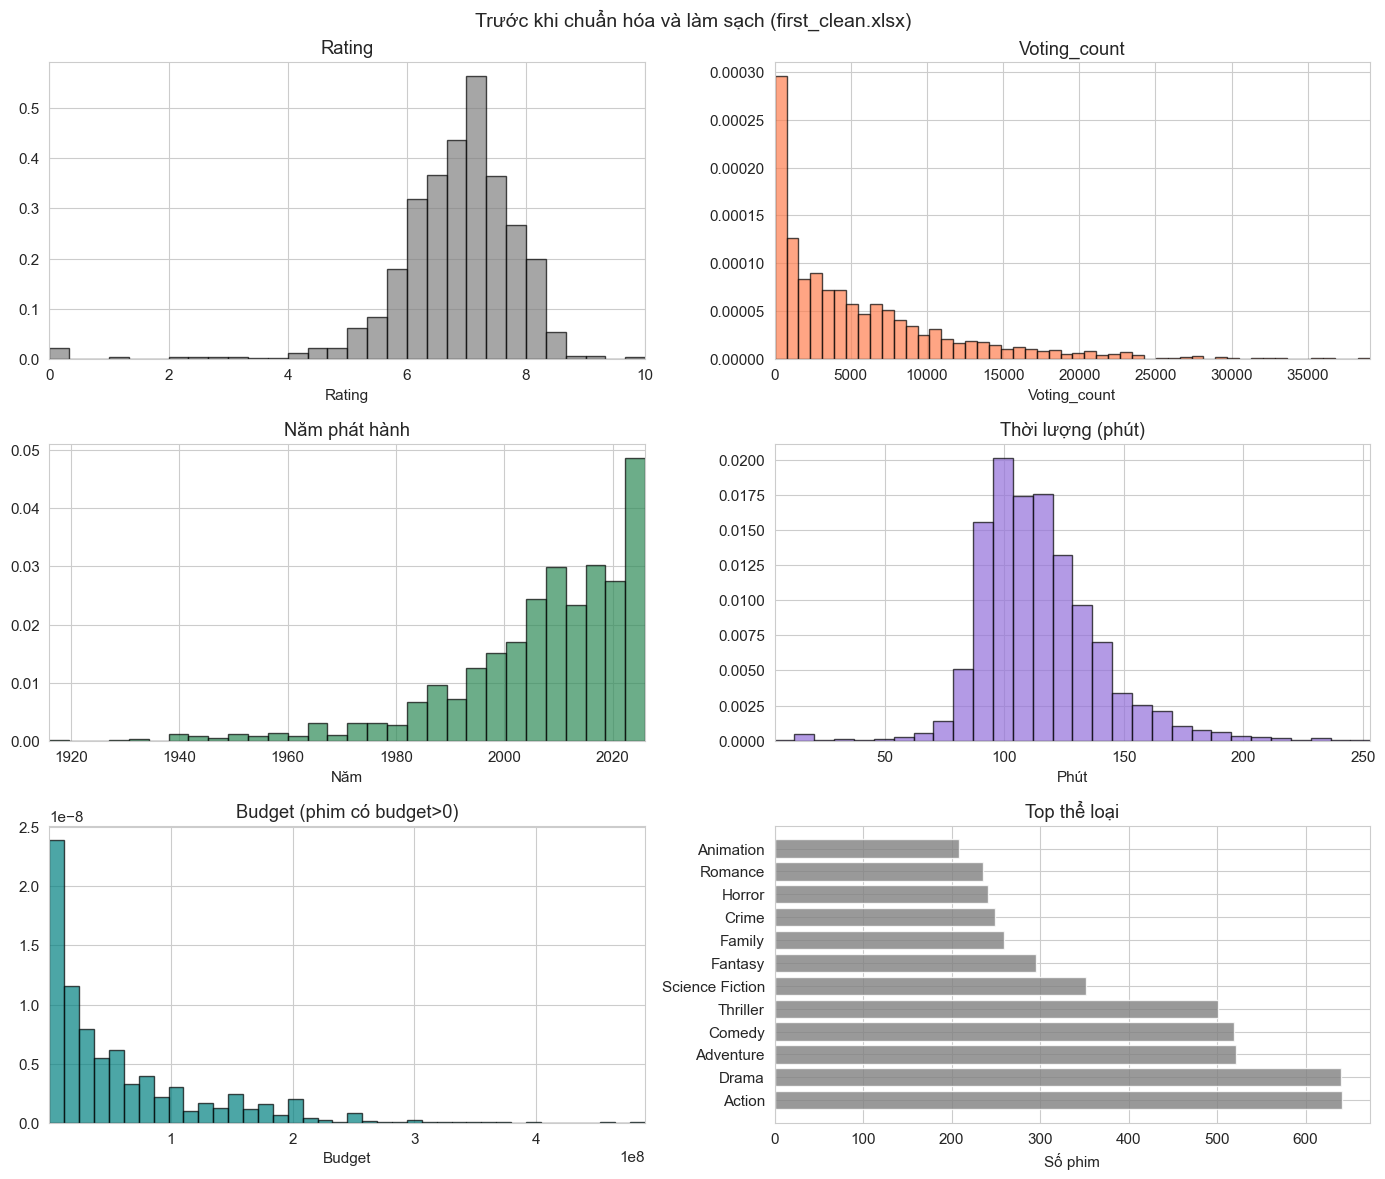

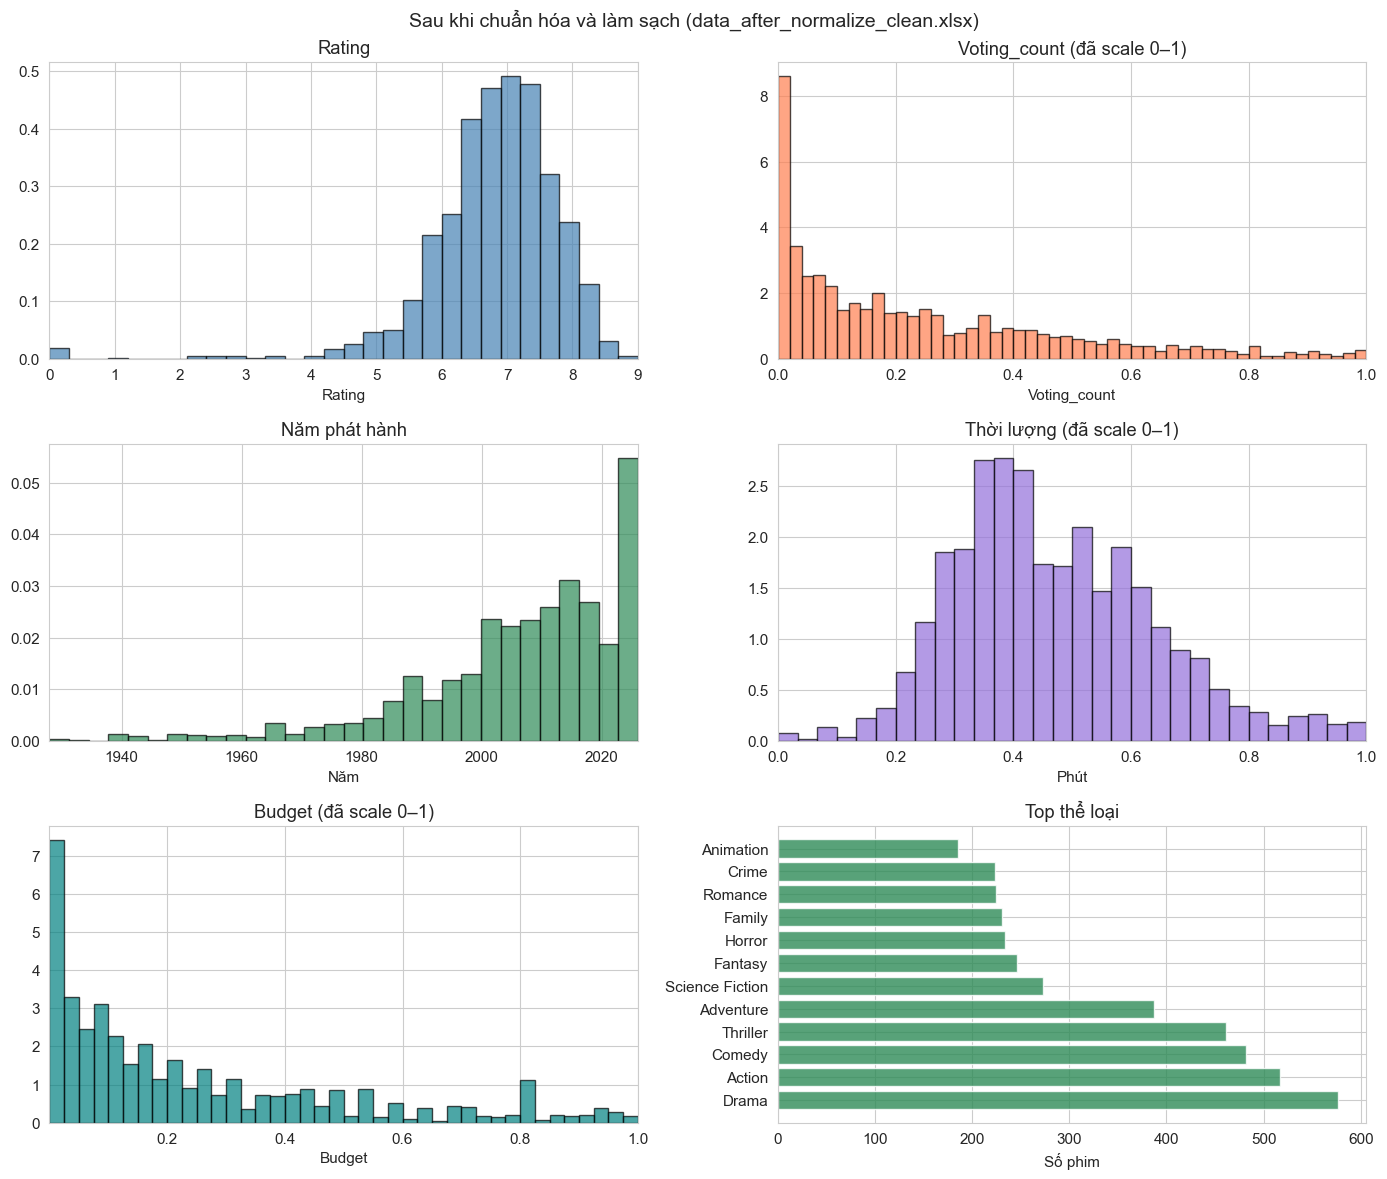

In [217]:
# Nguồn: Trước = first_clean.xlsx (gốc), Sau = data_after_normalize_clean.xlsx (đã chuẩn hóa định lượng 0–1 + lọc outlier)
PATH_FIRST = os.path.join(CLEAN_DIR, 'first_clean.xlsx')
PATH_AFTER = os.path.join(CLEAN_DIR, 'data_after_normalize_clean.xlsx')
df_truoc = pd.read_excel(PATH_FIRST)
df_sau = pd.read_excel(PATH_AFTER)
df_truoc['Runtime_min'] = pd.to_numeric(df_truoc.get('Run_time', df_truoc.get('Runtime_min')), errors='coerce')
df_truoc['Budget_num'] = pd.to_numeric(df_truoc.get('Budget', df_truoc.get('Budget_num')), errors='coerce')
df_sau['Runtime_min'] = pd.to_numeric(df_sau.get('Run_time', df_sau.get('Runtime_min')), errors='coerce')
df_sau['Budget_num'] = pd.to_numeric(df_sau.get('Budget', df_sau.get('Budget_num')), errors='coerce')

# Thang trục x: Trước = theo dữ liệu gốc, Sau = theo dữ liệu đã scale (0–1)
xlim_rating_t = (df_truoc['Rating'].dropna().min(), df_truoc['Rating'].dropna().max())
xlim_vc_t = (df_truoc['Voting_count'].dropna().min(), df_truoc['Voting_count'].dropna().max())
xlim_year_t = (df_truoc['Release_year'].min(), df_truoc['Release_year'].max())
rt_t = df_truoc['Runtime_min'].dropna()
xlim_rt_t = (rt_t.min(), rt_t.max()) if len(rt_t) > 0 else (None, None)
bud_t = df_truoc['Budget_num'].dropna(); bud_t = bud_t[bud_t > 0]
xlim_bud_t = (bud_t.min(), bud_t.max()) if len(bud_t) > 0 else (None, None)

xlim_rating_s = (df_sau['Rating'].dropna().min(), df_sau['Rating'].dropna().max())
xlim_vc_s = (df_sau['Voting_count'].dropna().min(), df_sau['Voting_count'].dropna().max())
xlim_year_s = (df_sau['Release_year'].min(), df_sau['Release_year'].max())
rt_sau = df_sau['Runtime_min'].dropna()
xlim_rt_s = (rt_sau.min(), rt_sau.max()) if len(rt_sau) > 0 else (None, None)
bud_sau = df_sau['Budget_num'].dropna(); bud_sau = bud_sau[bud_sau > 0]
xlim_bud_s = (bud_sau.min(), bud_sau.max()) if len(bud_sau) > 0 else (None, None)

# --- Đồ thị 1: Trước (first_clean.xlsx — giá trị gốc) ---
fig1, ax1 = plt.subplots(3, 2, figsize=(14, 12))
fig1.suptitle('Trước khi chuẩn hóa và làm sạch (first_clean.xlsx)', fontsize=14)
ax1[0,0].hist(df_truoc['Rating'].dropna(), bins=30, alpha=0.7, color='gray', edgecolor='black', density=True)
ax1[0,0].set_title('Rating')
ax1[0,0].set_xlabel('Rating')
ax1[0,0].set_xlim(xlim_rating_t)
ax1[0,1].hist(df_truoc['Voting_count'].dropna(), bins=50, alpha=0.7, color='coral', edgecolor='black', density=True)
ax1[0,1].set_title('Voting_count')
ax1[0,1].set_xlabel('Voting_count')
ax1[0,1].set_xlim(xlim_vc_t)
ax1[1,0].hist(df_truoc['Release_year'].dropna(), bins=30, alpha=0.7, color='seagreen', edgecolor='black', density=True)
ax1[1,0].set_title('Năm phát hành')
ax1[1,0].set_xlabel('Năm')
ax1[1,0].set_xlim(xlim_year_t)
if len(rt_t) > 0: ax1[1,1].hist(rt_t, bins=30, alpha=0.7, color='mediumpurple', edgecolor='black', density=True)
ax1[1,1].set_title('Thời lượng (phút)')
ax1[1,1].set_xlabel('Phút')
if xlim_rt_t[0] is not None: ax1[1,1].set_xlim(xlim_rt_t)
bud_t = df_truoc['Budget_num'].dropna(); bud_t = bud_t[bud_t > 0]
if len(bud_t) > 0: ax1[2,0].hist(bud_t, bins=40, alpha=0.7, color='teal', edgecolor='black', density=True)
ax1[2,0].set_title('Budget (phim có budget>0)')
ax1[2,0].set_xlabel('Budget')
if xlim_bud_t[0] is not None: ax1[2,0].set_xlim(xlim_bud_t)
g_t = df_truoc['Genre'].astype(str).str.split(', ').explode().str.strip().value_counts().head(12)
ax1[2,1].barh(range(len(g_t)), g_t.values, color='gray', alpha=0.8)
ax1[2,1].set_yticks(range(len(g_t)))
ax1[2,1].set_yticklabels(g_t.index)
ax1[2,1].set_title('Top thể loại')
ax1[2,1].set_xlabel('Số phim')
plt.tight_layout()
plt.show()

# --- Đồ thị 2: Sau (data_after_normalize_clean.xlsx — giá trị đã scale 0–1) ---
fig2, ax2 = plt.subplots(3, 2, figsize=(14, 12))
fig2.suptitle('Sau khi chuẩn hóa và làm sạch (data_after_normalize_clean.xlsx)', fontsize=14)
ax2[0,0].hist(df_sau['Rating'].dropna(), bins=30, alpha=0.7, color='steelblue', edgecolor='black', density=True)
ax2[0,0].set_title('Rating')
ax2[0,0].set_xlabel('Rating')
ax2[0,0].set_xlim(xlim_rating_s)
ax2[0,1].hist(df_sau['Voting_count'].dropna(), bins=50, alpha=0.7, color='coral', edgecolor='black', density=True)
ax2[0,1].set_title('Voting_count (đã scale 0–1)')
ax2[0,1].set_xlabel('Voting_count')
ax2[0,1].set_xlim(xlim_vc_s)
ax2[1,0].hist(df_sau['Release_year'], bins=30, alpha=0.7, color='seagreen', edgecolor='black', density=True)
ax2[1,0].set_title('Năm phát hành')
ax2[1,0].set_xlabel('Năm')
ax2[1,0].set_xlim(xlim_year_s)
if len(rt_sau) > 0: ax2[1,1].hist(rt_sau, bins=30, alpha=0.7, color='mediumpurple', edgecolor='black', density=True)
ax2[1,1].set_title('Thời lượng (đã scale 0–1)')
ax2[1,1].set_xlabel('Phút')
if xlim_rt_s[0] is not None: ax2[1,1].set_xlim(xlim_rt_s)
if len(bud_sau) > 0: ax2[2,0].hist(bud_sau, bins=40, alpha=0.7, color='teal', edgecolor='black', density=True)
ax2[2,0].set_title('Budget (đã scale 0–1)')
ax2[2,0].set_xlabel('Budget')
if xlim_bud_s[0] is not None: ax2[2,0].set_xlim(xlim_bud_s)
g_s = df_sau['Genre'].astype(str).str.split(', ').explode().str.strip().value_counts().head(12)
ax2[2,1].barh(range(len(g_s)), g_s.values, color='seagreen', alpha=0.8)
ax2[2,1].set_yticks(range(len(g_s)))
ax2[2,1].set_yticklabels(g_s.index)
ax2[2,1].set_title('Top thể loại')
ax2[2,1].set_xlabel('Số phim')
plt.tight_layout()
plt.show()

## 4. Mã hóa dữ liệu (Encoding)

Em mã hóa thể loại (Genre) bằng one-hot: tách chuỗi Genre theo dấu phẩy, lấy 12 thể loại có tần suất cao nhất, tạo các cột Genre_<tên> (giá trị 1 nếu phim thuộc thể loại đó, 0 nếu không). Code dùng df_clean['Genre'].str.split(', ') rồi explode và value_counts để chọn top 12, sau đó str.contains để gán 0/1 cho từng cột.

In [218]:
# --- Mã hóa thể loại (Genre): One-hot encoding cho top thể loại ---
# Tách từng thể loại (phân tách bằng ", ") và đếm tần suất
genres_flat = df_clean['Genre'].str.split(', ').explode().str.strip()
top_genres = genres_flat.value_counts().head(12).index.tolist()
for g in top_genres:
    col_name = 'Genre_' + g.replace(' ', '_').replace('&', 'and')
    df_clean[col_name] = df_clean['Genre'].str.contains(g, regex=False, na=False).astype(int)

genre_cols = [c for c in df_clean.columns if c.startswith('Genre_')]
print('Số cột one-hot thể loại:', len(genre_cols))
print('Ví dụ:', genre_cols[:5])
df_clean[['Genre'] + genre_cols[:5]].head(8)

Số cột one-hot thể loại: 12
Ví dụ: ['Genre_Drama', 'Genre_Action', 'Genre_Comedy', 'Genre_Thriller', 'Genre_Adventure']


,Genre,Genre_Drama,Genre_Action,Genre_Comedy,Genre_Thriller,Genre_Adventure
0,"Comedy, Drama",1,0,1,0,0
1,"Romance, Fantasy, Family, Drama",1,0,0,0,0
2,"Fantasy, Animation, Family",0,0,0,0,0
3,"Action, Adventure, Science Fiction",0,1,0,0,1
5,"Drama, Romance",1,0,0,0,0
6,"Family, Animation, Adventure, Comedy",0,0,1,0,1
8,"Comedy, Horror",0,0,1,0,0
9,"Drama, War, Action",1,1,0,0,0


## 5. Xây dựng và lựa chọn đặc trưng (Feature engineering)

Em tạo thêm các đặc trưng phục vụ phân tích và mô hình sau: Num_genres (số thể loại mỗi phim, đếm từ chuỗi Genre tách theo dấu phẩy); Voting_count_log = log(1 + Voting_count) để giảm độ lệch; Decade (thập kỷ phát hành, từ Release_year); Budget_log = log(1 + Budget) cho các phim có budget. Các đặc trưng này được thêm trực tiếp vào dataframe đang dùng.

In [219]:
# Số lượng thể loại mỗi phim (sau khi tách bằng dấu phẩy)
df_clean['Num_genres'] = df_clean['Genre'].str.split(',').str.len().fillna(0).astype(int)
# Log(Voting_count + 1) để giảm độ lệch (distribution skew)
df_clean['Voting_count_log'] = np.log1p(df_clean['Voting_count'])
# Thập kỷ phát hành (decade) — biến danh mục có thứ tự
df_clean['Decade'] = (df_clean['Release_year'] // 10) * 10
# Budget log (nếu có, nhiều giá trị 0 nên dùng log1p)
df_clean['Budget_log'] = np.log1p(df_clean['Budget_num'].fillna(0))

print('Một số đặc trưng đã tạo:')
df_clean[['Rating', 'Voting_count', 'Voting_count_log', 'Num_genres', 'Decade']].describe()

Một số đặc trưng đã tạo:


,Rating,Voting_count,Voting_count_log,Num_genres,Decade
count,1589.000000,1589.000000,1589.000000,1589.000000,1589.000000
mean,6.760667,0.243169,0.200759,2.763373,2001.969792
std,1.002142,0.240222,0.179725,0.990200,17.110814
min,0.000000,0.000000,0.000000,1.000000,1920.000000
25%,6.300000,0.043428,0.042512,2.000000,1990.000000
50%,6.900000,0.169277,0.156386,3.000000,2010.000000
75%,7.400000,0.379080,0.321417,3.000000,2010.000000
max,9.000000,1.000000,0.693147,6.000000,2020.000000


## 6. Trực quan hóa đa biến

Em vẽ scatter (Rating theo Voting_count, Release_year, Runtime), heatmap tương quan giữa các biến số, và (trong phần dưới) clustermap cùng t-SNE để quan sát cấu trúc dữ liệu và mối quan hệ giữa rating với các biến còn lại.

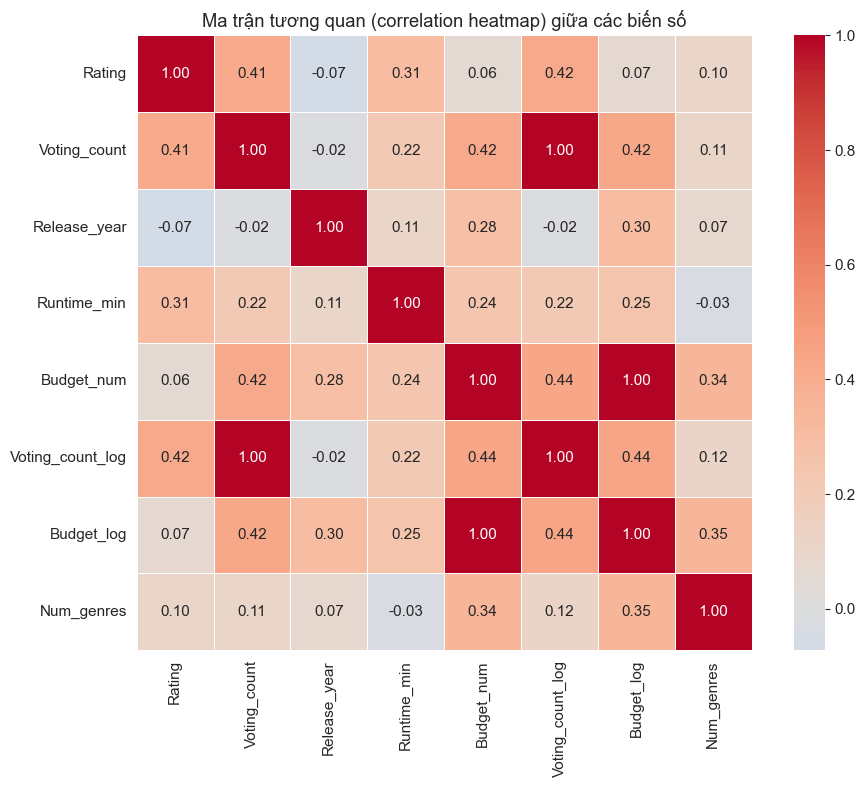

In [224]:
# Các biến số để tương quan (dùng Runtime_min đã tạo ở bước làm sạch)
num_cols = ['Rating', 'Voting_count', 'Release_year', 'Runtime_min', 'Budget_num', 'Voting_count_log','Budget_log', 'Num_genres']
num_cols = [c for c in num_cols if c in df_clean.columns]
df_num = df_clean[num_cols].copy()
corr = df_num.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Ma trận tương quan (correlation heatmap) giữa các biến số')
plt.tight_layout()
plt.show()

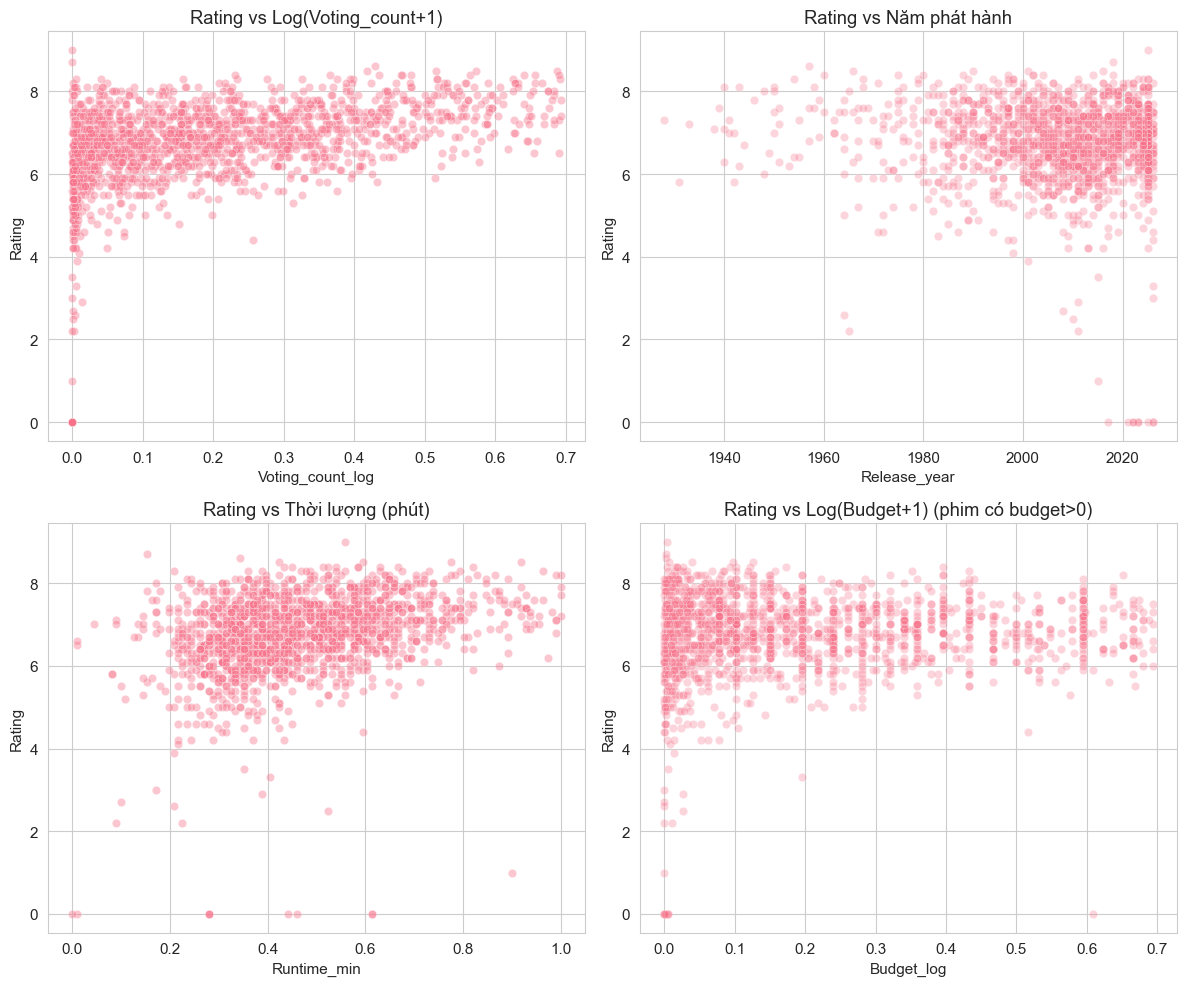

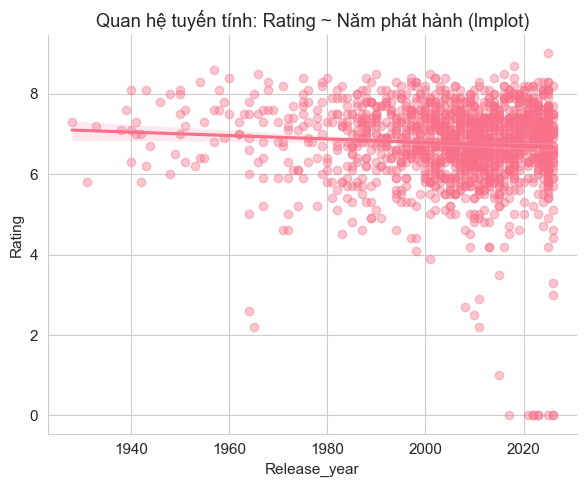

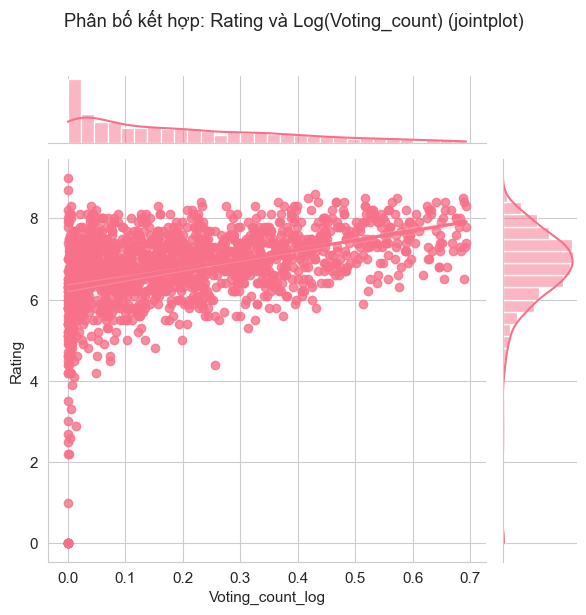

In [221]:
# Scatter + lmplot: mối quan hệ giữa Rating và các biến dự đoán
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.scatterplot(data=df_clean, x='Voting_count_log', y='Rating', alpha=0.4, ax=axes[0,0])
axes[0,0].set_title('Rating vs Log(Voting_count+1)')
sns.scatterplot(data=df_clean, x='Release_year', y='Rating', alpha=0.3, ax=axes[0,1])
axes[0,1].set_title('Rating vs Năm phát hành')
sns.scatterplot(data=df_clean.dropna(subset=['Runtime_min']), x='Runtime_min', y='Rating', alpha=0.4, ax=axes[1,0])
axes[1,0].set_title('Rating vs Thời lượng (phút)')
sns.scatterplot(data=df_clean[df_clean['Budget_num'] > 0], x='Budget_log', y='Rating', alpha=0.3, ax=axes[1,1])
axes[1,1].set_title('Rating vs Log(Budget+1) (phim có budget>0)')
plt.tight_layout()
plt.show()

# lmplot: đường hồi quy tuyến tính (seaborn)
sns.lmplot(data=df_clean, x='Release_year', y='Rating', height=5, aspect=1.2, scatter_kws={'alpha': 0.4})
plt.title('Quan hệ tuyến tính: Rating ~ Năm phát hành (lmplot)')
plt.tight_layout()
plt.show()

# Distribution plot (jointplot): Rating vs Voting_count_log
sns.jointplot(data=df_clean, x='Voting_count_log', y='Rating', kind='reg', height=6, marginal_kws=dict(bins=30))
plt.suptitle('Phân bố kết hợp: Rating và Log(Voting_count) (jointplot)', y=1.02)
plt.tight_layout()
plt.show()

### Clustermap và t-SNE

Em vẽ clustermap (seaborn) để gom nhóm biến và mẫu theo độ tương đồng, thấy được cấu trúc tương quan. Sau đó dùng t-SNE giảm chiều dữ liệu xuống 2D (sau khi chuẩn hóa StandardScaler), màu theo Rating để xem có xu hướng phân cụm theo điểm rating hay không.

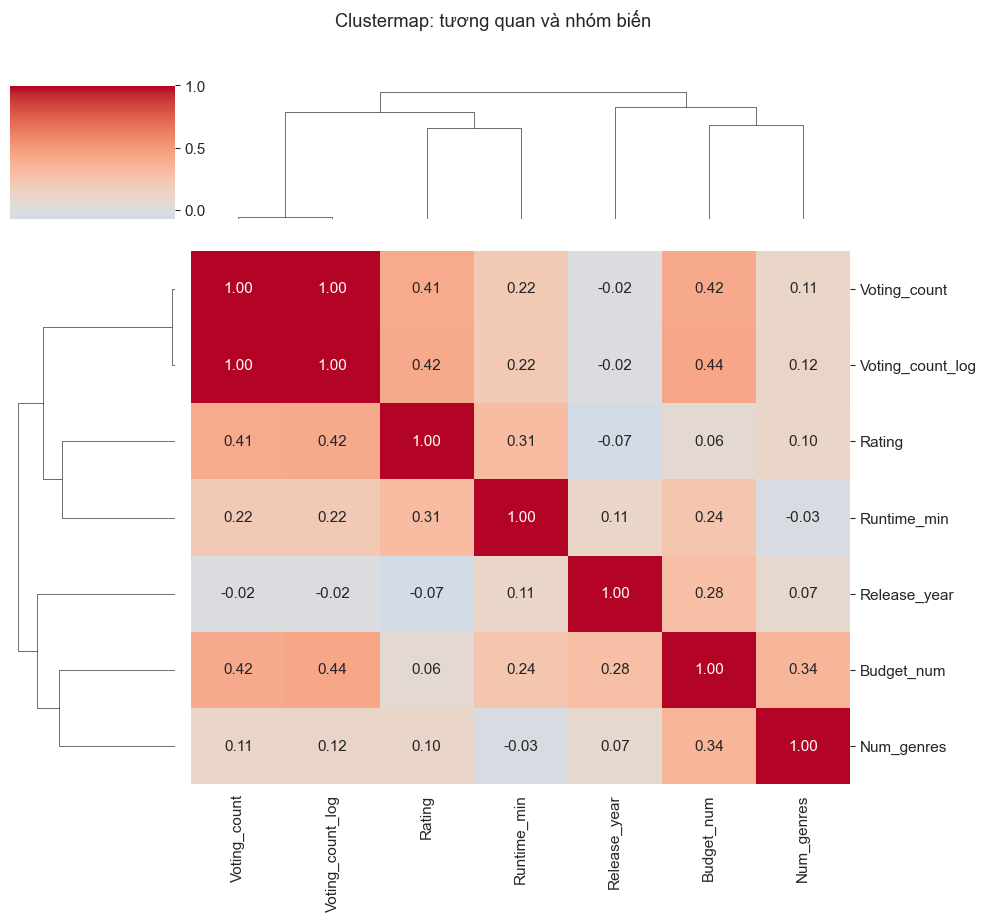

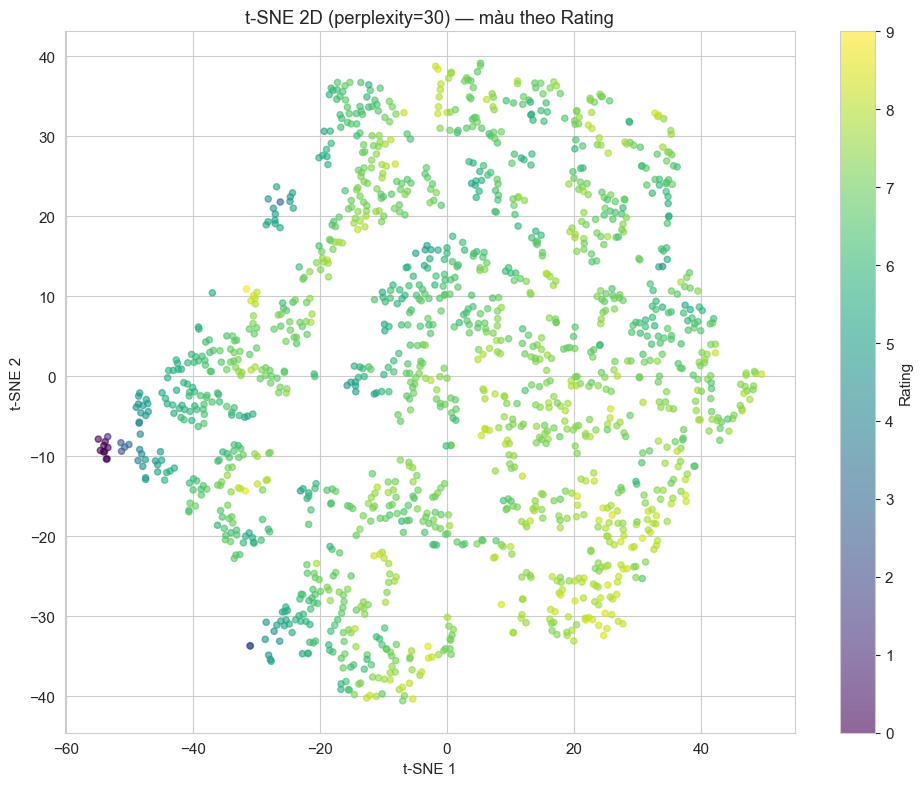

In [222]:
# Clustermap (seaborn): tương quan + hierarchical clustering
sns.clustermap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, figsize=(10, 9))
plt.suptitle('Clustermap: tương quan và nhóm biến', y=1.02)
plt.tight_layout()
plt.show()

# t-SNE: lấy mẫu để chạy nhanh (t-SNE tốn thời gian)
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Chỉ lấy các dòng đầy đủ num_cols (t-SNE cần dữ liệu số không missing)
df_tsne_pool = df_clean.dropna(subset=num_cols)

if len(df_tsne_pool) < 50:
    print(f'Không đủ dữ liệu để chạy t-SNE (cần >=50 dòng sau dropna, hiện có {len(df_tsne_pool)}).')
else:
    n_sample = min(1500, len(df_tsne_pool))
    df_tsne = df_tsne_pool.sample(n=n_sample, random_state=42, replace=False)

    X = df_tsne[num_cols].values
    X_scaled = StandardScaler().fit_transform(X)

    # Perplexity phải < số mẫu; chọn tự động để tránh lỗi
    perplexity = int(min(30, max(5, (len(df_tsne) - 1) // 3)))
    tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity, init='pca', learning_rate='auto')

    X_2d = tsne.fit_transform(X_scaled)
    df_tsne = df_tsne.copy()
    df_tsne['tsne1'] = X_2d[:, 0]
    df_tsne['tsne2'] = X_2d[:, 1]

    fig, ax = plt.subplots(figsize=(10, 8))
    scatter = ax.scatter(df_tsne['tsne1'], df_tsne['tsne2'], c=df_tsne['Rating'], cmap='viridis', alpha=0.6, s=20)
    plt.colorbar(scatter, label='Rating')
    ax.set_title(f't-SNE 2D (perplexity={perplexity}) — màu theo Rating')
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    plt.tight_layout()
    plt.show()

## 7. Kết luận

Về tính khả thi: Bài toán dự đoán rating phim (hồi quy) từ năm phát hành, số lượt bình chọn, thể loại, thời lượng và ngân sách là khả thi về mặt dữ liệu vì số mẫu sau làm sạch vẫn đủ lớn, biến mục tiêu Rating liên tục, và trực quan đa biến (scatter, heatmap, t-SNE) cho thấy có mối quan hệ tiềm ẩn giữa rating với các biến số; t-SNE màu theo rating có xu hướng gradient, gợi ý mô hình có thể học được pattern.

Tập đặc trưng đề xuất cho mô hình: các biến số (Voting_count hoặc Voting_count_log, Release_year, Runtime_min, Budget_num hoặc Budget_log, Num_genres, Decade) và các cột one-hot thể loại (Genre_Drama, Genre_Comedy, …). Có thể bổ sung tương tác hoặc đặc trưng từ text trong bước mô hình hóa sau. Hạn chế: Budget và Runtime ban đầu có missing, đã xử lý bằng dropna và lọc outlier; Voting_count lệch phải nên khi mô hình hóa nên dùng log.

## 8. Tài liệu tham khảo

- The Movie Database (TMDB): https://www.themoviedb.org
- TMDB API: https://developers.themoviedb.org/3
- Feature engineering: https://phamdinhkhanh.github.io/2019/01/07/Ky_thuat_feature_engineering.html
- t-SNE: https://www.datacamp.com/tutorial/introduction-t-sne

In [ ]:
# Lưu dữ liệu đã làm sạch (chỉ XLSX)
os.makedirs(CLEAN_DIR, exist_ok=True)

CLEAN_XLSX_PATH = os.path.join(CLEAN_DIR, 'final_clean.xlsx')
df_clean.to_excel(CLEAN_XLSX_PATH, index=False)
print('Đã lưu:', CLEAN_XLSX_PATH)
print('Số dòng:', len(df_clean), '| Số cột:', len(df_clean.columns))

Đã lưu: ..\clean data\movies_clean.xlsx
Số dòng: 1589 | Số cột: 25
